# Feature Exploration: Load Factor

This notebook explores whether **load factor** (passengers / available seats) from BITRE's Monthly Airline Performance dataset improves flight delay predictions. This came from the hypothesis that airlines operating at high load factors have less buffer for mishaps, such as fewer spare aircraft and shorter turnarounds. These may correlate with higher delay rates and help with the prediction.

 However, there is a serious limitation to the available data: they only provide a single load factor value for the entire domestic industry each month. This mean all airline-route combinations in a given month receive the same load factor. This reduces the feature to a monthly economic/demand indicator rather than a route-specific one.


## 1. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed")

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

%matplotlib inline
print("Setup complete.")

XGBoost available
Setup complete.


In [5]:
# Load BITRE Monthly Airline Performance — Domestic airlines sheet
ACTIVITY_FILE = '../data/raw/monthly-airline-performance-november-2025.xlsx'
SHEET_NAME = 'Domestic airlines'

print(f"Loading: {ACTIVITY_FILE}")
print(f"Sheet: {SHEET_NAME}")
print(f"File size: {os.path.getsize(ACTIVITY_FILE) / 1024:.1f} KB")

Loading: ../data/raw/monthly-airline-performance-november-2025.xlsx
Sheet: Domestic airlines
File size: 755.9 KB


## 2. Data Inspection & Cleaning

The Domestic airlines sheet has a multi-row header (rows 0-7) with annual summary rows interspersed in the data. The parsing below handles this structure.

In [6]:
# Read raw to show structure
df_raw = pd.read_excel(ACTIVITY_FILE, sheet_name=SHEET_NAME, header=None, nrows=12)
print("Raw file structure (first 12 rows):")
for i in range(len(df_raw)):
    vals = [str(v) for v in df_raw.iloc[i, :6].values]
    print(f"  Row {i}: {vals}")

print("\nRows 0-7 are header/metadata. Data starts at row 8.")
print("Annual summary rows (e.g. 'Year 2010 total') are interspersed.")

Raw file structure (first 12 rows):
  Row 0: ['Domestic airline performance', 'nan', 'nan', 'nan', 'nan', 'nan']
  Row 1: ['nan', 'nan', 'nan', 'nan', 'nan', 'nan']
  Row 2: ['Year', 'Month', 'Hours', 'Aircraft', 'Aircraft', 'Total rev']
  Row 3: ['nan', 'nan', 'flown', 'km flown', 'departures (a)', 'pax (U/D)']
  Row 4: ['nan', 'nan', 'nan', "('000)", 'nan', 'nan']
  Row 5: ['nan', 'nan', 'nan', 'nan', 'nan', 'nan']
  Row 6: ['nan', 'nan', 'nan', 'nan', 'nan', 'nan']
  Row 7: ['nan', 'nan', 'nan', 'nan', 'nan', 'nan']
  Row 8: ['1984', 'Jan', '34261.73333333333', '14985.157', '35917', '1021490']
  Row 9: ['1984', 'Feb', '29168.066666666666', '12494.823', '31756', '840094']
  Row 10: ['1984', 'Mar', '32455.566666666666', '13866.077', '34176', '940934']
  Row 11: ['1984', 'Apr', '31691.35', '13611.255', '32388', '978119']

Rows 0-7 are header/metadata. Data starts at row 8.
Annual summary rows (e.g. 'Year 2010 total') are interspersed.


In [7]:
# Load data, skipping the 8-row header
df_activity = pd.read_excel(ACTIVITY_FILE, sheet_name=SHEET_NAME, header=None, skiprows=8)

# Assign column names based on the header structure
df_activity.columns = [
    'year', 'month_name', 'hours_flown', 'aircraft_km_flown_000', 'aircraft_departures',
    'total_rev_pax_ud', 'freight_tonnes_ud', 'mail_tonnes_ud',
    'total_rev_pax_tob', 'total_rev_pax_tob_inc_intl',
    'freight_tonnes_tob', 'mail_tonnes_tob',
    'total_rpk_000', 'pax_tonne_km_000', 'freight_tonne_km_000',
    'mail_tonne_km_000', 'total_tonne_km_000',
    'available_seat_km_000', 'available_tonne_km_000', 'available_seats_000',
    'pax_load_factor_pct', 'weight_load_factor_pct',
    'total_charter_pax_tob', 'charter_aircraft_departures'
]

print(f"Raw rows loaded: {len(df_activity)}")
print(f"Columns: {len(df_activity.columns)}")

Raw rows loaded: 761
Columns: 24


In [8]:
# Filter to actual monthly data rows (numeric year, valid month name)
df_activity['year_numeric'] = pd.to_numeric(df_activity['year'], errors='coerce')
valid_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'June',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_act = df_activity[
    df_activity['year_numeric'].notna() &
    df_activity['month_name'].isin(valid_months)
].copy()

df_act['year'] = df_act['year_numeric'].astype(int)
df_act = df_act.drop(columns=['year_numeric'])

# Standardise month names ('June' -> 'Jun')
df_act['month_name'] = df_act['month_name'].replace({'June': 'Jun'})

# Create proper date column
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_act['month_num'] = df_act['month_name'].map(month_map)
df_act['year_month'] = df_act['year'].astype(str) + '-' + df_act['month_num'].astype(str).str.zfill(2)

# Normalise load factor from percentage to proportion
df_act['load_factor'] = pd.to_numeric(df_act['pax_load_factor_pct'], errors='coerce') / 100.0

# Also extract total passengers and available seats
df_act['total_passengers'] = pd.to_numeric(df_act['total_rev_pax_ud'], errors='coerce')
df_act['available_seats_000'] = pd.to_numeric(df_act['available_seats_000'], errors='coerce')

# Exclude COVID period (Apr-Dec 2020)
covid_mask = (df_act['year'] == 2020) & (df_act['month_num'] >= 4)
rows_before = len(df_act)
df_act = df_act[~covid_mask].copy()
print(f"Removed {rows_before - len(df_act)} COVID period rows (Apr-Dec 2020)")

# Filter to relevant years (2010 onwards, matching training data)
df_act = df_act[df_act['year'] >= 2009].copy()

print(f"\nCleaned data: {len(df_act)} monthly records")
print(f"Date range: {df_act['year_month'].min()} to {df_act['year_month'].max()}")
print(f"\nLoad factor summary:")
print(df_act['load_factor'].describe())

Removed 9 COVID period rows (Apr-Dec 2020)

Cleaned data: 194 monthly records
Date range: 2009-01 to 2025-11

Load factor summary:
count    194.000000
mean       0.776767
std        0.062709
min        0.455049
25%        0.765041
50%        0.787072
75%        0.809155
max        0.870137
Name: load_factor, dtype: float64


In [9]:
# Preview cleaned data
print("Sample data (2019):")
cols_preview = ['year', 'month_name', 'year_month', 'total_passengers',
                'available_seats_000', 'load_factor']
print(df_act[df_act['year'] == 2019][cols_preview].to_string(index=False))

Sample data (2019):
 year month_name year_month  total_passengers  available_seats_000  load_factor
 2019        Jan    2019-01           5030043             6531.848     0.789404
 2019        Feb    2019-02           4465621             5847.803     0.772773
 2019        Mar    2019-03           5024090             6478.464     0.787782
 2019        Apr    2019-04           5112777             6562.790     0.803355
 2019        May    2019-05           4848365             6447.647     0.773745
 2019        Jun    2019-06           4669723             6152.990     0.782956
 2019        Jul    2019-07           5413049             6839.926     0.822687
 2019        Aug    2019-08           5157000             6456.619     0.824692
 2019        Sep    2019-09           5148686             6471.758     0.818746
 2019        Oct    2019-10           5607945             6829.707     0.844665
 2019        Nov    2019-11           5212654             6350.001     0.838328
 2019        Dec    

## 3. Exploratory Analysis of Load Factor

Note: Since this is aggregate industry data (not per-airline or per-route), the load factor represents overall domestic aviation demand each month.

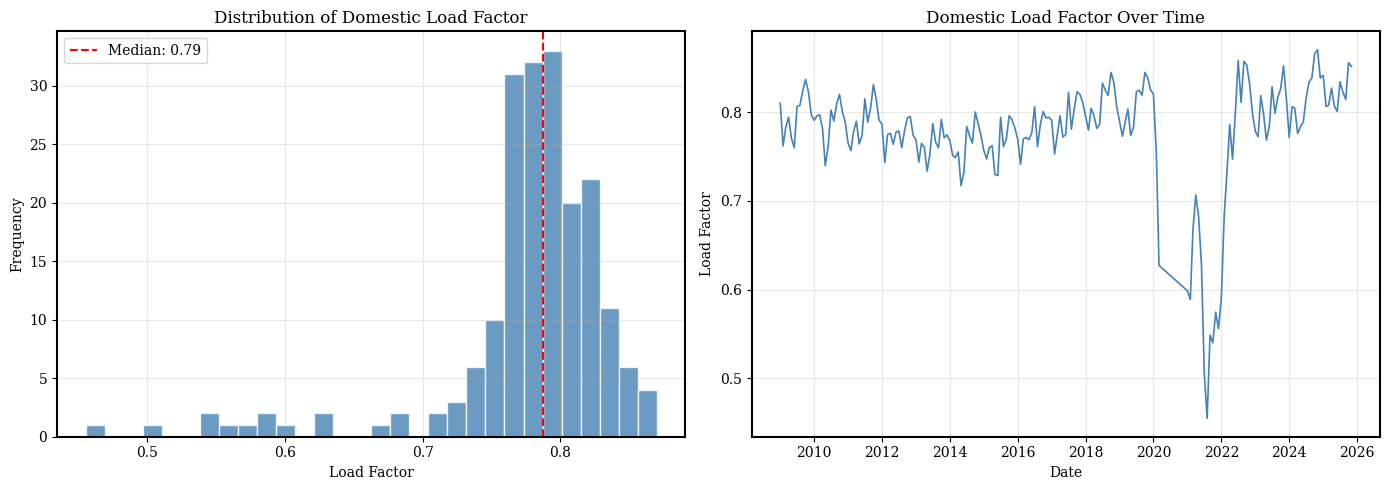

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax = axes[0]
ax.hist(df_act['load_factor'].dropna(), bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Load Factor')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Domestic Load Factor')
median_lf = df_act['load_factor'].median()
ax.axvline(median_lf, color='red', linestyle='--', label=f'Median: {median_lf:.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Time series
ax = axes[1]
ts = df_act.sort_values('year_month')
ax.plot(pd.to_datetime(ts['year_month']), ts['load_factor'], color='steelblue', linewidth=1.2)
ax.set_xlabel('Date')
ax.set_ylabel('Load Factor')
ax.set_title('Domestic Load Factor Over Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

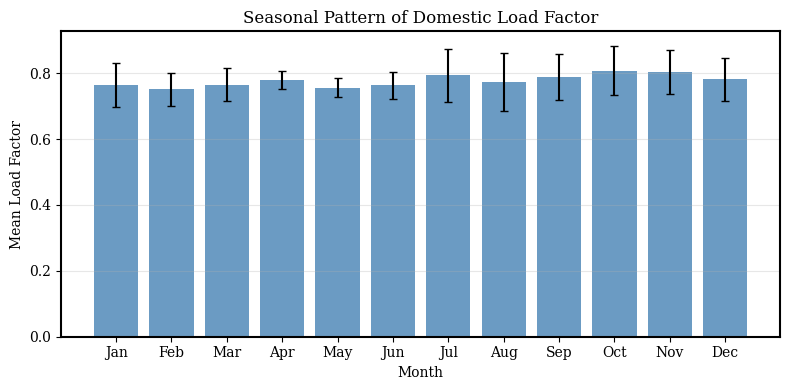

Seasonal load factor:
  Jan: 0.764 ± 0.067
  Feb: 0.750 ± 0.051
  Mar: 0.764 ± 0.050
  Apr: 0.780 ± 0.027
  May: 0.756 ± 0.030
  Jun: 0.763 ± 0.042
  Jul: 0.793 ± 0.079
  Aug: 0.772 ± 0.088
  Sep: 0.788 ± 0.069
  Oct: 0.808 ± 0.075
  Nov: 0.803 ± 0.067
  Dec: 0.782 ± 0.065


In [11]:
# Seasonal pattern
monthly_avg = df_act.groupby('month_num')['load_factor'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_avg['month_num'], monthly_avg['mean'],
       yerr=monthly_avg['std'], color='steelblue', alpha=0.8, capsize=3)
ax.set_xlabel('Month')
ax.set_ylabel('Mean Load Factor')
ax.set_title('Seasonal Pattern of Domestic Load Factor')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Seasonal load factor:")
for _, row in monthly_avg.iterrows():
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    print(f"  {month_names[int(row['month_num'])-1]}: {row['mean']:.3f} ± {row['std']:.3f}")

## 4. Merge with Existing Training Data

Since the load factor data is industry-aggregate (one value per month), the merge is on `year_month` only. Every airline-route combination in a given month receives the same load factor.

In [12]:
# Load existing training data
df_train = pd.read_csv('../data/processed/ml_training_data_multiroute_hols.csv')
df_train['year_month_dt'] = pd.to_datetime(df_train['year_month'])
df_train['month_num'] = df_train['year_month_dt'].dt.month
df_train['year'] = df_train['year'].astype(int)
df_train['airline_route'] = df_train['airline'] + '_' + df_train['departing_port'] + '_' + df_train['arriving_port']
df_train['route'] = df_train['departing_port'] + '_' + df_train['arriving_port']

print(f"Training data: {df_train.shape}")
print(f"Date range: {df_train['year_month'].min()} to {df_train['year_month'].max()}")

Training data: (20523, 62)
Date range: 2010-01 to 2025-11


In [13]:
# Prepare load factor for merging (year_month only)
df_lf = df_act[['year_month', 'load_factor']].copy()
df_lf = df_lf.groupby('year_month')['load_factor'].mean().reset_index()

print(f"Load factor records for merge: {len(df_lf)}")
print(f"Merge key: year_month")
print(f"\nNote: This is AGGREGATE industry load factor.")
print(f"All airline-routes in a given month receive the same value.")

# Merge
df_merged = df_train.merge(df_lf, on='year_month', how='left')

matched = df_merged['load_factor'].notna().sum()
total = len(df_merged)
match_rate = matched / total * 100

print(f"\nMerge results:")
print(f"  Total training rows:  {total}")
print(f"  Matched (with LF):    {matched} ({match_rate:.1f}%)")
print(f"  Unmatched (no LF):    {total - matched} ({100 - match_rate:.1f}%)")

if total - matched > 0:
    unmatched = df_merged[df_merged['load_factor'].isna()]
    print(f"\n  Unmatched year_months:")
    print(f"  {sorted(unmatched['year_month'].unique())}")

Load factor records for merge: 194
Merge key: year_month

Note: This is AGGREGATE industry load factor.
All airline-routes in a given month receive the same value.

Merge results:
  Total training rows:  20523
  Matched (with LF):    20523 (100.0%)
  Unmatched (no LF):    0 (0.0%)


## 5. Correlation with Delay Rate

In [14]:
# Only use rows that have load factor data
df_with_lf = df_merged[df_merged['load_factor'].notna()].copy()
print(f"Rows with load factor data: {len(df_with_lf)}")

# Overall correlation
corr_delay = df_with_lf['load_factor'].corr(df_with_lf['delay_rate'])
corr_high_delay = df_with_lf['load_factor'].corr(df_with_lf['is_high_delay'])
corr_sectors = df_with_lf['load_factor'].corr(df_with_lf['sectors_scheduled'])

print(f"\nCorrelations:")
print(f"  load_factor vs delay_rate:       r = {corr_delay:.4f}")
print(f"  load_factor vs is_high_delay:    r = {corr_high_delay:.4f}")
print(f"  load_factor vs sectors_scheduled: r = {corr_sectors:.4f}")

print(f"\nInterpretation:")
if abs(corr_delay) < 0.05:
    print(f"  Very weak correlation with delay_rate — unlikely to be useful.")
elif abs(corr_delay) < 0.15:
    print(f"  Weak correlation with delay_rate — marginal signal.")
else:
    print(f"  Moderate correlation with delay_rate — worth testing.")

if abs(corr_sectors) > 0.7:
    print(f"  ⚠ High correlation with sectors_scheduled — multicollinearity risk.")

Rows with load factor data: 20523

Correlations:
  load_factor vs delay_rate:       r = 0.2470
  load_factor vs is_high_delay:    r = 0.2090
  load_factor vs sectors_scheduled: r = 0.0741

Interpretation:
  Moderate correlation with delay_rate — worth testing.


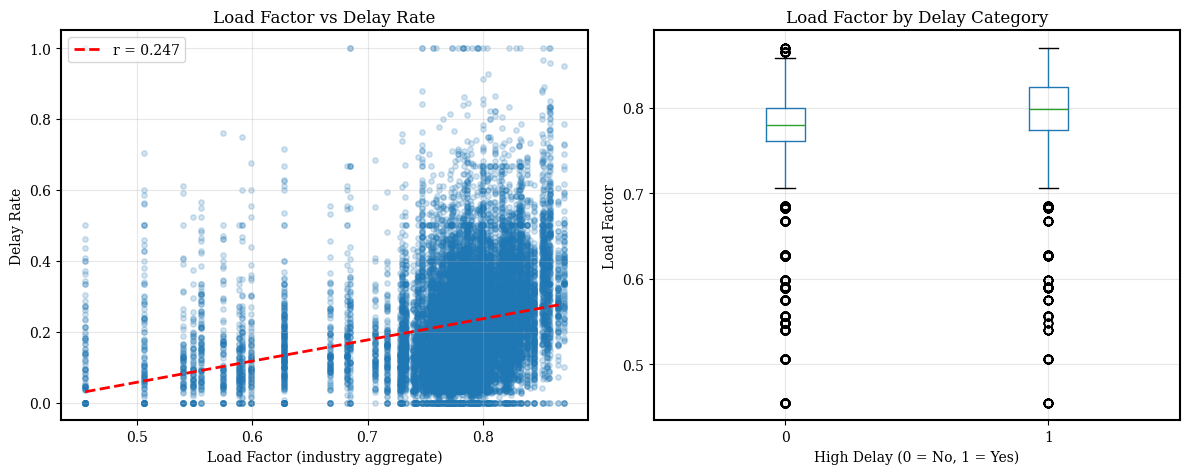

In [15]:
# Scatter plot: load_factor vs delay_rate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(df_with_lf['load_factor'], df_with_lf['delay_rate'], alpha=0.2, s=15)
z = np.polyfit(df_with_lf['load_factor'].values, df_with_lf['delay_rate'].values, 1)
p = np.poly1d(z)
x_line = np.linspace(df_with_lf['load_factor'].min(), df_with_lf['load_factor'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'r = {corr_delay:.3f}')
ax.set_xlabel('Load Factor (industry aggregate)')
ax.set_ylabel('Delay Rate')
ax.set_title('Load Factor vs Delay Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot: load factor by high/low delay
ax = axes[1]
df_with_lf.boxplot(column='load_factor', by='is_high_delay', ax=ax)
ax.set_xlabel('High Delay (0 = No, 1 = Yes)')
ax.set_ylabel('Load Factor')
ax.set_title('Load Factor by Delay Category')
plt.suptitle('')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Per-route correlation
print("Correlation: load_factor vs delay_rate by route")
print(f"{'='*60}")
print(f"{'Route':<25} {'r':>8} {'n':>6}")
print(f"{'-'*60}")

route_corrs = []
for route in sorted(df_with_lf['route'].unique()):
    route_data = df_with_lf[df_with_lf['route'] == route]
    if len(route_data) > 10:
        r = route_data['load_factor'].corr(route_data['delay_rate'])
        print(f"{route:<25} {r:>8.4f} {len(route_data):>6}")
        route_corrs.append({'route': route, 'r': r, 'n': len(route_data)})

route_corr_df = pd.DataFrame(route_corrs)
print(f"\nMean |r| across routes: {route_corr_df['r'].abs().mean():.4f}")
print(f"Routes with |r| > 0.1: {(route_corr_df['r'].abs() > 0.1).sum()} / {len(route_corr_df)}")
print(f"\nNote: Since load_factor is the same for all routes in a given month,")
print(f"variation in per-route r reflects route-specific seasonal patterns.")

Correlation: load_factor vs delay_rate by route
Route                            r      n
------------------------------------------------------------
Adelaide_Brisbane           0.2438    671
Adelaide_Darwin            -0.2001     18
Adelaide_Melbourne          0.3556    797
Adelaide_Perth              0.2455    654
Adelaide_Sydney             0.3868    705
Brisbane_Adelaide           0.2276    671
Brisbane_Darwin             0.0895    584
Brisbane_Hobart             0.2722    344
Brisbane_Melbourne          0.2420    720
Brisbane_Perth              0.2131    461
Brisbane_Sydney             0.3142    696
Darwin_Adelaide             0.1111     18
Darwin_Brisbane             0.0743    585
Darwin_Melbourne            0.1622    504
Darwin_Perth                0.0823    464
Darwin_Sydney               0.3160    305
Hobart_Brisbane             0.2341    343
Hobart_Melbourne            0.3477    730
Hobart_Sydney               0.3177    617
Melbourne_Adelaide          0.3477    797
Melbourne

## 6. Feature Engineering

In [17]:
# Sort for lag computation
df_with_lf = df_with_lf.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

# Since load_factor is the same for all airline-routes in a month,
# the lag is computed per airline-route but is effectively the industry
# load factor from the previous month
df_with_lf['load_factor_lag1'] = df_with_lf.groupby('airline_route')['load_factor'].shift(1)

# Nonlinear transforms to amplify effects near capacity (LF → 1.0)
# exp(LF): e^0.70 = 2.01, e^0.80 = 2.23, e^0.85 = 2.34, e^0.90 = 2.46
#   → amplifies high-end differences
# -log(1 - LF): -log(0.30) = 1.20, -log(0.20) = 1.61, -log(0.15) = 1.90, -log(0.10) = 2.30
#   → diverges as LF approaches 1.0 (spare capacity → 0)
df_with_lf['load_factor_exp'] = np.exp(df_with_lf['load_factor'])
df_with_lf['load_factor_log_inv'] = -np.log(1 - df_with_lf['load_factor'].clip(upper=0.99))

df_with_lf['load_factor_lag1_exp'] = np.exp(df_with_lf['load_factor_lag1'])
df_with_lf['load_factor_lag1_log_inv'] = -np.log(1 - df_with_lf['load_factor_lag1'].clip(upper=0.99))

# Interaction: load factor under weather stress
df_with_lf['extreme_weather_days_total'] = (
    df_with_lf['extreme_weather_days_dep'] + df_with_lf['extreme_weather_days_arr']
)
df_with_lf['lf_x_extreme_weather'] = df_with_lf['load_factor'] * df_with_lf['extreme_weather_days_total']
df_with_lf['lf_exp_x_extreme_weather'] = df_with_lf['load_factor_exp'] * df_with_lf['extreme_weather_days_total']

print("Features created:")
print("  Raw:      load_factor, load_factor_lag1")
print("  Exp:      load_factor_exp, load_factor_lag1_exp")
print("  -Log(1-x): load_factor_log_inv, load_factor_lag1_log_inv")
print("  Interact: lf_x_extreme_weather, lf_exp_x_extreme_weather")

# Compare correlations across transforms
print(f"\nCorrelations with delay_rate:")
transform_features = [
    'load_factor', 'load_factor_exp', 'load_factor_log_inv',
    'load_factor_lag1', 'load_factor_lag1_exp', 'load_factor_lag1_log_inv',
    'lf_x_extreme_weather', 'lf_exp_x_extreme_weather'
]
for feat in transform_features:
    r = df_with_lf[feat].corr(df_with_lf['delay_rate'])
    print(f"  {feat:<35} r = {r:.4f}")

Features created:
  Raw:      load_factor, load_factor_lag1
  Exp:      load_factor_exp, load_factor_lag1_exp
  -Log(1-x): load_factor_log_inv, load_factor_lag1_log_inv
  Interact: lf_x_extreme_weather, lf_exp_x_extreme_weather

Correlations with delay_rate:
  load_factor                         r = 0.2470
  load_factor_exp                     r = 0.2585
  load_factor_log_inv                 r = 0.2868
  load_factor_lag1                    r = 0.1899
  load_factor_lag1_exp                r = 0.1981
  load_factor_lag1_log_inv            r = 0.2200
  lf_x_extreme_weather                r = 0.0483
  lf_exp_x_extreme_weather            r = 0.0383


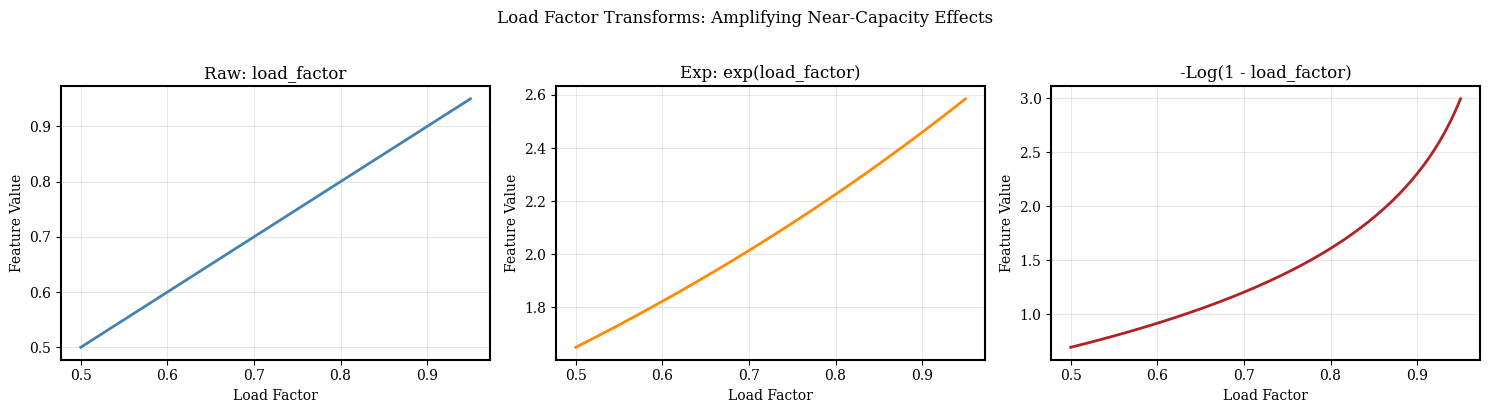

Key insight: -log(1 - LF) diverges as LF → 1, making it the most
aggressive transform for penalising near-capacity months.
exp(LF) provides moderate amplification at the high end.


In [18]:
# Visualise transforms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(0.5, 0.95, 200)

ax = axes[0]
ax.plot(x, x, color='steelblue', linewidth=2)
ax.set_title('Raw: load_factor')
ax.set_xlabel('Load Factor')
ax.set_ylabel('Feature Value')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, np.exp(x), color='darkorange', linewidth=2)
ax.set_title('Exp: exp(load_factor)')
ax.set_xlabel('Load Factor')
ax.set_ylabel('Feature Value')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(x, -np.log(1 - x), color='firebrick', linewidth=2)
ax.set_title('-Log(1 - load_factor)')
ax.set_xlabel('Load Factor')
ax.set_ylabel('Feature Value')
ax.grid(True, alpha=0.3)

plt.suptitle('Load Factor Transforms: Amplifying Near-Capacity Effects', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: -log(1 - LF) diverges as LF → 1, making it the most")
print("aggressive transform for penalising near-capacity months.")
print("exp(LF) provides moderate amplification at the high end.")

# Multicollinearity check
df_with_lf['delay_rate_lag1'] = df_with_lf.groupby('airline_route')['delay_rate'].shift(1)

existing_features = ['sectors_scheduled', 'delay_rate_lag1', 'rainy_days_arr',
                     'temp_volatility_dep', 'temp_volatility_arr']

print("Multicollinearity check: load_factor variants vs existing features")
print(f"{'='*70}")
for lf_feat in ['load_factor', 'load_factor_exp', 'load_factor_log_inv']:
    print(f"\n  {lf_feat}:")
    for feat in existing_features:
        if feat in df_with_lf.columns:
            r = df_with_lf[lf_feat].corr(df_with_lf[feat])
            flag = " ⚠ HIGH" if abs(r) > 0.7 else ""
            print(f"    vs {feat:<25} r = {r:.4f}{flag}")

# Also check inter-correlation between transforms
print(f"\n  Inter-correlation of transforms:")
print(f"    raw vs exp:     r = {df_with_lf['load_factor'].corr(df_with_lf['load_factor_exp']):.4f}")
print(f"    raw vs log_inv: r = {df_with_lf['load_factor'].corr(df_with_lf['load_factor_log_inv']):.4f}")
print(f"    exp vs log_inv: r = {df_with_lf['load_factor_exp'].corr(df_with_lf['load_factor_log_inv']):.4f}")

In [19]:
# Prepare data following 8b pipeline
# Filter low-volume airline-routes
volume_threshold = 50
airline_route_volume = df_with_lf.groupby('airline_route')['sectors_scheduled'].mean().reset_index()
airline_route_volume.columns = ['airline_route', 'avg_volume']
high_volume_ar = airline_route_volume[airline_route_volume['avg_volume'] >= volume_threshold]['airline_route'].tolist()

df_model = df_with_lf[df_with_lf['airline_route'].isin(high_volume_ar)].copy()

# Exclude anomalous routes (same as 8b)
anomalous_routes = ['Melbourne_Hobart', 'Adelaide_Sydney', 'Perth_Brisbane']
df_model = df_model[~df_model['route'].isin(anomalous_routes)].copy()

# Feature engineering (same as 8b)
df_model['delay_rate_lag1'] = df_model.groupby('airline_route')['delay_rate'].shift(1)
df_model['delay_rate_lag2'] = df_model.groupby('airline_route')['delay_rate'].shift(2)
df_model['delay_rate_gradient'] = df_model['delay_rate_lag1'] - df_model['delay_rate_lag2']

df_model['month_sin'] = np.sin(2 * np.pi * df_model['month_num'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month_num'] / 12)

airline_dummies = pd.get_dummies(df_model['airline'], prefix='airline')
df_model = pd.concat([df_model, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

route_dummies = pd.get_dummies(df_model['route'], prefix='route')
df_model = pd.concat([df_model, route_dummies], axis=1)
route_cols = list(route_dummies.columns)

df_model['rainy_days_arr_exp'] = np.exp(df_model['rainy_days_arr'] / df_model['rainy_days_arr'].max())
df_model['temp_volatility_total'] = df_model['temp_volatility_dep'] + df_model['temp_volatility_arr']
df_model['temp_volatility_total_exp'] = np.exp(df_model['temp_volatility_total'] / df_model['temp_volatility_total'].max())
df_model['extreme_weather_days_total'] = df_model['extreme_weather_days_dep'] + df_model['extreme_weather_days_arr']

# Compute load factor transforms
df_model['load_factor_exp'] = np.exp(df_model['load_factor'])
df_model['load_factor_log_inv'] = -np.log(1 - df_model['load_factor'].clip(upper=0.99))
df_model['load_factor_lag1_exp'] = np.exp(df_model['load_factor_lag1'])
df_model['load_factor_lag1_log_inv'] = -np.log(1 - df_model['load_factor_lag1'].clip(upper=0.99))

# Interaction terms (one per transform)
df_model['lf_x_extreme_weather'] = df_model['load_factor'] * df_model['extreme_weather_days_total']
df_model['lf_exp_x_extreme_weather'] = df_model['load_factor_exp'] * df_model['extreme_weather_days_total']
df_model['lf_log_inv_x_extreme_weather'] = df_model['load_factor_log_inv'] * df_model['extreme_weather_days_total']

# Drop NaN from lags
df_clean = df_model.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient',
                                    'load_factor', 'load_factor_lag1']).copy()

print(f"Model-ready rows: {len(df_clean)}")
print(f"Load factor transform features available: load_factor, load_factor_exp, load_factor_log_inv")

Model-ready rows: 11471
Load factor transform features available: load_factor, load_factor_exp, load_factor_log_inv


In [20]:
# Train/Validation/Test split (same as 8b)
train_mask = (((df_clean['year'] >= 2010) & (df_clean['year'] <= 2017)) | (df_clean['year'] == 2023))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2024))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2023): {train_mask.sum()} samples")
print(f"Validation (2018, 2024): {val_mask.sum()} samples")
print(f"Test (2019, 2025+):      {test_mask.sum()} samples")

Train (2010-2017, 2023): 6843 samples
Validation (2018, 2024): 1589 samples
Test (2019, 2025+):      1451 samples


In [21]:
# Define feature sets: baseline + 3 load factor variants
BASE_FEATURES = (
    airline_cols + route_cols +
    ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled'] +
    ['rainy_days_arr_exp', 'delay_rate_gradient', 'temp_volatility_total_exp', 'extreme_weather_days_total'] +
    ['n_public_holidays_total', 'pct_school_holiday']
)

# Raw load factor
LF_RAW_FEATURES = BASE_FEATURES + ['load_factor', 'load_factor_lag1', 'lf_x_extreme_weather']

# Exp transform: exp(LF) — moderate amplification at high end
LF_EXP_FEATURES = BASE_FEATURES + ['load_factor_exp', 'load_factor_lag1_exp', 'lf_exp_x_extreme_weather']

# -Log(1-LF) transform: diverges as LF → 1.0 — most aggressive
LF_LOG_FEATURES = BASE_FEATURES + ['load_factor_log_inv', 'load_factor_lag1_log_inv', 'lf_log_inv_x_extreme_weather']

FEATURE_SETS = {
    'Baseline': BASE_FEATURES,
    'LF Raw': LF_RAW_FEATURES,
    'LF Exp': LF_EXP_FEATURES,
    'LF -Log(1-x)': LF_LOG_FEATURES,
}

print(f"Feature set sizes:")
for name, feats in FEATURE_SETS.items():
    extra = len(feats) - len(BASE_FEATURES)
    print(f"  {name:<15} {len(feats)} features" + (f" (+{extra})" if extra > 0 else ""))

Feature set sizes:
  Baseline        40 features
  LF Raw          43 features (+3)
  LF Exp          43 features (+3)
  LF -Log(1-x)    43 features (+3)


In [22]:
def train_and_evaluate(features, label):
    """Train all models and return results dict."""
    X_train = df_clean.loc[train_mask, features].values
    X_val = df_clean.loc[val_mask, features].values
    X_test = df_clean.loc[test_mask, features].values

    y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
    y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
    y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

    y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
    y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
    y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    results = {'label': label}

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_s, y_train_reg)
    results['ridge_val_r2'] = r2_score(y_val_reg, ridge.predict(X_val_s))
    results['ridge_test_r2'] = r2_score(y_test_reg, ridge.predict(X_test_s))
    results['ridge_test_rmse'] = np.sqrt(mean_squared_error(y_test_reg, ridge.predict(X_test_s)))

    # Random Forest Regression
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train_reg)
    results['rf_val_r2'] = r2_score(y_val_reg, rf.predict(X_val))
    results['rf_test_r2'] = r2_score(y_test_reg, rf.predict(X_test))
    results['rf_test_rmse'] = np.sqrt(mean_squared_error(y_test_reg, rf.predict(X_test)))

    # XGBoost Classification
    if HAS_XGB:
        xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                     min_child_weight=5, random_state=42, n_jobs=-1)
        xgb_clf.fit(X_train, y_train_clf, eval_set=[(X_val, y_val_clf)], verbose=False)
        xgb_test_pred = xgb_clf.predict(X_test)
        xgb_test_proba = xgb_clf.predict_proba(X_test)[:, 1]
        results['xgb_val_f1'] = f1_score(y_val_clf, xgb_clf.predict(X_val))
        results['xgb_test_f1'] = f1_score(y_test_clf, xgb_test_pred)
        results['xgb_test_auc'] = roc_auc_score(y_test_clf, xgb_test_proba)

    # Store predictions for route-level analysis
    results['ridge_test_pred'] = ridge.predict(X_test_s)
    results['rf_test_pred'] = rf.predict(X_test)
    results['rf_importance'] = rf.feature_importances_
    results['features'] = features

    return results

# Train all 4 variants
all_results = {}
for name, feats in FEATURE_SETS.items():
    print(f"\n--- {name} ({len(feats)} features) ---")
    res = train_and_evaluate(feats, name)
    all_results[name] = res
    print(f"  Ridge R² (test): {res['ridge_test_r2']:.4f}  |  RF R² (test): {res['rf_test_r2']:.4f}", end='')
    if HAS_XGB:
        print(f"  |  XGB F1 (test): {res['xgb_test_f1']:.4f}")
    else:
        print()

print("\nAll variants trained.")


--- Baseline (40 features) ---
  Ridge R² (test): 0.4610  |  RF R² (test): 0.4833  |  XGB F1 (test): 0.7410

--- LF Raw (43 features) ---
  Ridge R² (test): 0.4829  |  RF R² (test): 0.4884  |  XGB F1 (test): 0.7637

--- LF Exp (43 features) ---
  Ridge R² (test): 0.4824  |  RF R² (test): 0.4889  |  XGB F1 (test): 0.7597

--- LF -Log(1-x) (43 features) ---
  Ridge R² (test): 0.4771  |  RF R² (test): 0.4874  |  XGB F1 (test): 0.7609

All variants trained.


In [23]:
# 4-way comparison table
print("=" * 95)
print("MODEL COMPARISON: Baseline vs Load Factor Transforms")
print("=" * 95)

baseline = all_results['Baseline']

metrics = [
    ('Ridge Val R²', 'ridge_val_r2'),
    ('Ridge Test R²', 'ridge_test_r2'),
    ('Ridge Test RMSE', 'ridge_test_rmse'),
    ('RF Val R²', 'rf_val_r2'),
    ('RF Test R²', 'rf_test_r2'),
    ('RF Test RMSE', 'rf_test_rmse'),
]
if HAS_XGB:
    metrics.extend([
        ('XGB Val F1', 'xgb_val_f1'),
        ('XGB Test F1', 'xgb_test_f1'),
        ('XGB Test AUC', 'xgb_test_auc'),
    ])

variant_names = ['LF Raw', 'LF Exp', 'LF -Log(1-x)']

# Header
print(f"\n{'Metric':<18} {'Baseline':>10}", end='')
for v in variant_names:
    print(f" {v:>13}", end='')
print()
print("-" * (18 + 10 + 13 * len(variant_names)))

for name, key in metrics:
    b = baseline[key]
    print(f"{name:<18} {b:>10.4f}", end='')
    for v in variant_names:
        val = all_results[v][key]
        delta = val - b
        sign = '+' if delta > 0 else ''
        print(f"  {val:.4f}({sign}{delta:.4f})", end='')
    print()

# Highlight best variant per metric
print(f"\n{'Best variant per metric:'}")
for name, key in metrics:
    best_name = 'Baseline'
    best_val = baseline[key]
    # For RMSE, lower is better
    is_lower_better = 'RMSE' in name
    for v in variant_names:
        val = all_results[v][key]
        if (is_lower_better and val < best_val) or (not is_lower_better and val > best_val):
            best_val = val
            best_name = v
    delta = best_val - baseline[key]
    sign = '+' if delta > 0 else ''
    print(f"  {name:<18} → {best_name} ({sign}{delta:.4f})")

MODEL COMPARISON: Baseline vs Load Factor Transforms

Metric               Baseline        LF Raw        LF Exp  LF -Log(1-x)
-------------------------------------------------------------------
Ridge Val R²           0.4087  0.4587(+0.0500)  0.4586(+0.0499)  0.4550(+0.0463)
Ridge Test R²          0.4610  0.4829(+0.0219)  0.4824(+0.0214)  0.4771(+0.0161)
Ridge Test RMSE        0.0850  0.0833(-0.0017)  0.0833(-0.0017)  0.0838(-0.0013)
RF Val R²              0.4147  0.4143(-0.0004)  0.4147(-0.0000)  0.4142(-0.0005)
RF Test R²             0.4833  0.4884(+0.0051)  0.4889(+0.0057)  0.4874(+0.0042)
RF Test RMSE           0.0833  0.0828(-0.0004)  0.0828(-0.0005)  0.0829(-0.0003)
XGB Val F1             0.7155  0.7568(+0.0413)  0.7582(+0.0427)  0.7547(+0.0392)
XGB Test F1            0.7410  0.7637(+0.0227)  0.7597(+0.0187)  0.7609(+0.0199)
XGB Test AUC           0.8605  0.8724(+0.0119)  0.8722(+0.0118)  0.8721(+0.0116)

Best variant per metric:
  Ridge Val R²       → LF Raw (+0.0500)
  Ridge Tes

In [24]:
# Route-level R² comparison (Ridge) across all variants
df_test_data = df_clean[test_mask].copy()
test_indices = df_clean[test_mask].index

variant_names_all = ['Baseline', 'LF Raw', 'LF Exp', 'LF -Log(1-x)']

print("Route-Level R² Comparison (Ridge)")
print("=" * 90)
print(f"{'Route':<22}", end='')
for v in variant_names_all:
    print(f" {v:>14}", end='')
print(f" {'Best':>14}")
print("-" * 90)

route_comparison = []
for route in sorted(df_test_data['route'].unique()):
    mask = df_test_data['route'] == route
    idx = df_test_data[mask].index
    pos = [list(test_indices).index(i) for i in idx]
    y_true = df_test_data.loc[idx, 'delay_rate'].values

    if len(y_true) < 5:
        continue

    row = {'route': route}
    best_r2 = -999
    best_name = ''

    for v in variant_names_all:
        r2 = r2_score(y_true, all_results[v]['ridge_test_pred'][pos])
        row[v] = r2
        if r2 > best_r2:
            best_r2 = r2
            best_name = v

    row['best'] = best_name
    route_comparison.append(row)

    print(f"{route:<22}", end='')
    for v in variant_names_all:
        print(f" {row[v]:>14.4f}", end='')
    print(f" {best_name:>14}")

route_comp_df = pd.DataFrame(route_comparison)
print("-" * 90)

# Count wins per variant
print(f"\nWins per variant (highest R² per route):")
for v in variant_names_all:
    wins = (route_comp_df['best'] == v).sum()
    print(f"  {v:<15} {wins}/{len(route_comp_df)} routes")

Route-Level R² Comparison (Ridge)
Route                        Baseline         LF Raw         LF Exp   LF -Log(1-x)           Best
------------------------------------------------------------------------------------------
Adelaide_Brisbane              0.4067         0.3967         0.3958         0.3894       Baseline
Adelaide_Melbourne             0.4818         0.5158         0.5167         0.5047         LF Exp
Adelaide_Perth                 0.5319         0.5968         0.5972         0.5957         LF Exp
Brisbane_Adelaide              0.2380         0.3336         0.3355         0.3342         LF Exp
Brisbane_Melbourne             0.3474         0.4318         0.4340         0.4375   LF -Log(1-x)
Brisbane_Perth                 0.2618         0.3312         0.3337         0.3433   LF -Log(1-x)
Brisbane_Sydney                0.3370         0.4185         0.4183         0.4195   LF -Log(1-x)
Hobart_Melbourne               0.5670         0.5243         0.5228         0.5119       Ba

In [25]:
# Feature importance comparison across LF variants (RF)
lf_feature_names = {
    'LF Raw': ['load_factor', 'load_factor_lag1', 'lf_x_extreme_weather'],
    'LF Exp': ['load_factor_exp', 'load_factor_lag1_exp', 'lf_exp_x_extreme_weather'],
    'LF -Log(1-x)': ['load_factor_log_inv', 'load_factor_lag1_log_inv', 'lf_log_inv_x_extreme_weather'],
}

print("Feature Importance of LF Features (RF) by Variant")
print("=" * 70)

for variant in ['LF Raw', 'LF Exp', 'LF -Log(1-x)']:
    res = all_results[variant]
    imp_df = pd.DataFrame({
        'Feature': res['features'],
        'Importance': res['rf_importance']
    }).sort_values('Importance', ascending=False)

    print(f"\n{variant}:")
    lf_feats = lf_feature_names[variant]
    for feat in lf_feats:
        rank = list(imp_df['Feature']).index(feat) + 1
        imp = imp_df[imp_df['Feature'] == feat]['Importance'].values[0]
        print(f"  {feat:<40} rank {rank:>2}/{len(res['features'])}, importance = {imp:.4f}")

# Show top 15 features for the best-performing LF variant
# Determine best variant by average of Ridge R² and RF R²
best_variant = max(
    ['LF Raw', 'LF Exp', 'LF -Log(1-x)'],
    key=lambda v: (all_results[v]['ridge_test_r2'] + all_results[v]['rf_test_r2']) / 2
)
print(f"\n\nTop 15 Features — Best Variant: {best_variant}")
print("-" * 55)
best_res = all_results[best_variant]
best_imp = pd.DataFrame({
    'Feature': best_res['features'],
    'Importance': best_res['rf_importance']
}).sort_values('Importance', ascending=False)

best_lf_feats = lf_feature_names[best_variant]
for i, (_, row) in enumerate(best_imp.head(15).iterrows()):
    marker = " ◀ LF" if row['Feature'] in best_lf_feats else ""
    print(f"  {i+1:>2}. {row['Feature']:<35} {row['Importance']:.4f}{marker}")

Feature Importance of LF Features (RF) by Variant

LF Raw:
  load_factor                              rank  2/43, importance = 0.0674
  load_factor_lag1                         rank  5/43, importance = 0.0293
  lf_x_extreme_weather                     rank  8/43, importance = 0.0192

LF Exp:
  load_factor_exp                          rank  2/43, importance = 0.0677
  load_factor_lag1_exp                     rank  5/43, importance = 0.0293
  lf_exp_x_extreme_weather                 rank  8/43, importance = 0.0191

LF -Log(1-x):
  load_factor_log_inv                      rank  2/43, importance = 0.0666
  load_factor_lag1_log_inv                 rank  5/43, importance = 0.0288
  lf_log_inv_x_extreme_weather             rank  8/43, importance = 0.0202


Top 15 Features — Best Variant: LF Exp
-------------------------------------------------------
   1. delay_rate_lag1                     0.6577
   2. load_factor_exp                     0.0677 ◀ LF
   3. delay_rate_gradient                 

## 8. Summary and Observations

In [27]:
print("=" * 80)
print("FEATURE EXPLORATION: LOAD FACTOR — CONCLUSIONS")
print("=" * 80)

baseline = all_results['Baseline']

print(f"\n1. DATA LIMITATION:")
print(f"   The BITRE Monthly Airline Performance data provides industry-aggregate")
print(f"   load factor only (one value per month for all domestic airlines combined).")
print(f"   No per-route or per-airline breakdown is available.")

print(f"\n2. CORRELATION WITH DELAY RATE:")
print(f"   Overall r = {corr_delay:.4f}")
print(f"   vs sectors_scheduled r = {corr_sectors:.4f}")

print(f"\n3. MODEL IMPACT (Test Set):")
print(f"   {'Variant':<15} {'Ridge R²':>10} {'RF R²':>10}", end='')
if HAS_XGB:
    print(f" {'XGB F1':>10}")
else:
    print()
print(f"   {'-'*50}")
for name in ['Baseline', 'LF Raw', 'LF Exp', 'LF -Log(1-x)']:
    res = all_results[name]
    print(f"   {name:<15} {res['ridge_test_r2']:>10.4f} {res['rf_test_r2']:>10.4f}", end='')
    if HAS_XGB:
        print(f" {res['xgb_test_f1']:>10.4f}")
    else:
        print()

# Deltas vs baseline
print(f"\n   Deltas vs Baseline:")
for name in ['LF Raw', 'LF Exp', 'LF -Log(1-x)']:
    res = all_results[name]
    d_ridge = res['ridge_test_r2'] - baseline['ridge_test_r2']
    d_rf = res['rf_test_r2'] - baseline['rf_test_r2']
    print(f"   {name:<15} Ridge: {d_ridge:+.4f}  RF: {d_rf:+.4f}", end='')
    if HAS_XGB:
        d_xgb = res['xgb_test_f1'] - baseline['xgb_test_f1']
        print(f"  XGB: {d_xgb:+.4f}")
    else:
        print()

print(f"\n4. ROUTE-LEVEL IMPACT:")
for v in ['Baseline', 'LF Raw', 'LF Exp', 'LF -Log(1-x)']:
    wins = (route_comp_df['best'] == v).sum()
    if wins > 0:
        print(f"   {v}: best on {wins}/{len(route_comp_df)} routes")

FEATURE EXPLORATION: LOAD FACTOR — CONCLUSIONS

1. DATA LIMITATION:
   The BITRE Monthly Airline Performance data provides industry-aggregate
   load factor only (one value per month for all domestic airlines combined).
   No per-route or per-airline breakdown is available.

2. CORRELATION WITH DELAY RATE:
   Overall r = 0.2470
   vs sectors_scheduled r = 0.0741

3. MODEL IMPACT (Test Set):
   Variant           Ridge R²      RF R²     XGB F1
   --------------------------------------------------
   Baseline            0.4610     0.4833     0.7410
   LF Raw              0.4829     0.4884     0.7637
   LF Exp              0.4824     0.4889     0.7597
   LF -Log(1-x)        0.4771     0.4874     0.7609

   Deltas vs Baseline:
   LF Raw          Ridge: +0.0219  RF: +0.0051  XGB: +0.0227
   LF Exp          Ridge: +0.0214  RF: +0.0057  XGB: +0.0187
   LF -Log(1-x)    Ridge: +0.0161  RF: +0.0042  XGB: +0.0199

4. ROUTE-LEVEL IMPACT:
   Baseline: best on 8/21 routes
   LF Raw: best on 2/21 rout

### Observations

- Results are a bit mixed, but the best performing transform overall is LF Raw (no transformation)
- Overall, positive improvements, especially for Ridge (regression) and XGBoost (classification) models
- For future improvements, route-level or airline-level load factor data (if available) would be a stronger test of this hypothesis. The aggregate data tested here do not capture airline-specific or route-specific capacity pressure.

## 9. Next step

Adding load factor looks promising, it will be added to the model.

The next notebook will explore adding route-specific biases to account for the different mean dealy rates of each route.